# BT1

In [7]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from myLibs_v2 import genPoints
import os
import glob
import cv2
import RF_Model as model
import os
from PIL import Image
import myRFLibs


In [10]:
model.load_model("forestNumber.pkl")

Model loaded from forestNumber.pkl


# Define functions

In [9]:
# Init node
class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx    
        self.threshold = threshold  
        self.left = left                  
        self.right = right                
        self.value = value                

    def is_leaf(self):
        return self.value is not None

# Calculate entropy
def calEntropy(y):
    if len(y) == 0:
        return 0
    # Sử dụng np.unique thay cho value_counts vì y là NumPy array
    _, counts = np.unique(y, return_counts=True)
    entropy = 0
    for count in counts:
        p = count / len(y)
        entropy -= p * math.log2(p)
    return entropy

# Calculate Informative gain
def calIG(X, y, current_entropy, max_features=None):
    listIG = []
    best_gain = -1
    best_feature_idx = None
    best_threshold = None
    
    n_features = X.shape[1]
    
    if max_features is None:
        feature_indices = np.arange(n_features) #
    elif max_features == 'sqrt':
        n_sub = int(math.sqrt(n_features))
        feature_indices = np.random.choice(n_features, n_sub, replace=False) 
    else:
        feature_indices = np.random.choice(n_features, min(max_features, n_features), replace=False)

    
    for prob in feature_indices:
        thresholds = np.unique(X[:, prob])
        # Convert analog data to true/false data
        for thresh in thresholds:
            left_mask = X[:, prob] <= thresh
            right_mask = X[:, prob] > thresh
            
            labelTrue = y[left_mask]
            labelFalse = y[right_mask]
            
            if len(labelTrue) == 0 or len(labelFalse) == 0:
                continue
                
            proDiTrue = len(labelTrue) / len(X)
            proDiFalse = len(labelFalse) / len(X)
            
            entropyTrue = calEntropy(labelTrue)
            entropyFalse = calEntropy(labelFalse)
            
            entropyDi = (proDiTrue * entropyTrue) + (proDiFalse * entropyFalse)
            IG = current_entropy - entropyDi
            
            if IG > best_gain:
                best_gain = IG
                best_feature_idx = prob
                best_threshold = thresh
                
    return best_feature_idx, best_threshold, best_gain

# Build tree
def build_tree(X, y, current_depth=0, max_depth=5, parent_label=None, max_features='sqrt'):
    unique_labels = np.unique(y)
    if len(y) == 0:
        return Node(value=parent_label)
    if len(unique_labels) == 1:
        return Node(value=unique_labels[0])
    if current_depth >= max_depth:
        vals, counts = np.unique(y, return_counts=True)
        return Node(value=vals[np.argmax(counts)])

    current_entropy = calEntropy(y)
    
    best_feature_idx, best_threshold, best_gain = calIG(X, y, current_entropy, max_features)

    if best_gain <= 1e-7 or best_feature_idx is None:
        vals, counts = np.unique(y, return_counts=True)
        return Node(value=vals[np.argmax(counts)])
        
    # Divide left and right data
    left_mask = X[:, best_feature_idx] <= best_threshold
    right_mask = X[:, best_feature_idx] > best_threshold
    
    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]

    left_child = build_tree(X_left, y_left, current_depth + 1, max_depth, max_features=max_features)
    right_child = build_tree(X_right, y_right, current_depth + 1, max_depth, max_features=max_features)

    return Node(feature_idx=best_feature_idx, threshold=best_threshold, left=left_child, right=right_child)

# Predict
def predict(node, sample):
    if node.is_leaf():
        return node.value
    
    if sample[node.feature_idx] <= node.threshold:
        return predict(node.left, sample)
    else:
        return predict(node.right, sample)

# Predict full tree 
def predict_tree(tree, X): 
    return np.array([predict(tree, x) for x in X]) 

def print_tree(node, depth=0):
    indent = "   " * depth
    if node.is_leaf():
        print(f"{indent}➔ Kết luận Lá: {node.value}")
    else:
        print(f"{indent}[Nếu {node.feature_name} == 1]:")
        print_tree(node.left, depth + 1)
        print(f"{indent}[Nếu {node.feature_name} == 0]:")
        print_tree(node.right, depth + 1)

# Build forest
def build_forest(X, y, n_trees, max_depth=5, max_features = None):    
    forest = [] 
    n_samples = X.shape[0]
    for _ in range(n_trees):
        indices = np.random.choice(n_samples, n_samples, replace=True) 
        X_sample, y_sample = X[indices], y[indices] 
        tree = build_tree(X_sample, y_sample, max_depth=max_depth, max_features=max_features) 
        forest.append(tree) 
    return forest
def predict_forest(forest, X):
    all_preds = np.array([predict_tree(tree, X) for tree in forest]) 
    # Majority voting 
    final_preds = [] 
    for i in range(X.shape[0]): 
        votes, counts = np.unique(all_preds[:, i], return_counts=True) 
        final_preds.append(votes[np.argmax(counts)]) 
    return np.array(final_preds) 
def Visualize(X,y,forest):  
# -------------------- Visualize ----------------------------  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1  
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1  
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),  
                         np.arange(y_min, y_max, 0.05))  
    grid_points = np.c_[xx.ravel(), yy.ravel()]  
    Z = predict_forest(grid_points, forest).reshape(xx.shape)  
 
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')  
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=15)  
    plt.title("NumPy Random Forest Decision Boundary")  
    plt.xlabel("Feature 1")  
    plt.ylabel("Feature 2")  
    plt.grid(True)  

def load_mnist_test_data(test_dir):
    """
    Hàm load dữ liệu ảnh từ thư mục test và chuyển thành dạng NumPy array phẳng.
    Giả định cấu trúc thư mục: New_MNIST/test/0/, New_MNIST/test/1/, ...
    """
    X_test = []
    y_test = []
    
    # Kiểm tra thư mục có tồn tại không
    if not os.path.exists(test_dir):
        raise FileNotFoundError(f"Không tìm thấy thư mục: {test_dir}")
        
    # Duyệt qua từng thư mục con (mỗi thư mục con là một nhãn lớp: '0', '1', '2'...)
    for label_dir in sorted(os.listdir(test_dir)):
        label_path = os.path.join(test_dir, label_dir)
        
        # Chỉ xử lý nếu đó là một thư mục
        if os.path.isdir(label_path):
            label = int(label_dir) # Chuyển tên thư mục thành nhãn số
            
            # Duyệt qua từng file ảnh trong thư mục nhãn
            for img_name in os.listdir(label_path):
                img_path = os.path.join(label_path, img_name)
                
                try:
                    # Mở ảnh và chuyển sang ảnh xám (L) để đảm bảo pixel từ 0-255
                    with Image.open(img_path).convert('L') as img:
                        # Chuyển ảnh thành mảng numpy phẳng (ví dụ 28x28 -> 784)
                        img_flatten = np.array(img).flatten()
                        
                        X_test.append(img_flatten)
                        y_test.append(label)
                except Exception as e:
                    # Bỏ qua nếu gặp file lỗi hoặc file hệ thống không phải ảnh
                    continue
                    
    return np.array(X_test), np.array(y_test)

In [20]:
# 1. Đọc dữ liệu từ file Excel
file_name = "Mamal_Reptile_data.xlsx"
df = pd.read_excel(file_name)

# Giữ nguyên tên các cột đặc trưng để hiển thị cây cho đẹp
feature_names = ['toothed', 'hair', 'breathes', 'legs']
X = df[feature_names].values  # NumPy array
y = df['Species'].values       # NumPy array
# Tiến hành huấn luyện và xây dựng cây từ dữ liệu gốc
tree_root = build_forest(X, y, max_depth=5,n_trees=2)

print("--- CẤU TRÚC CÂY QUYẾT ĐỊNH CỦA BẠN ---")
# print_tree(tree_root)

print("\n--- THỬ NGHIỆM DỰ ĐOÁN MỘT CON VẬT MỚI ---")
# Thử tạo một con vật có: toothed=1, hair=0, breathes=1, legs=1
test_animal = np.array([[1, 0, 1, 1]])
prediction = predict_forest(tree_root, test_animal)
print(f"Đặc trưng con vật: {test_animal}")
print(f"Kết quả dự đoán loài: {prediction}")


--- CẤU TRÚC CÂY QUYẾT ĐỊNH CỦA BẠN ---

--- THỬ NGHIỆM DỰ ĐOÁN MỘT CON VẬT MỚI ---
Đặc trưng con vật: [[1 0 1 1]]
Kết quả dự đoán loài: ['Reptile']


C:\Users\MSI\AppData\Local\Temp\ipykernel_19300\1763091201.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_chosen)(np.linspace(0, 1, num_classes))


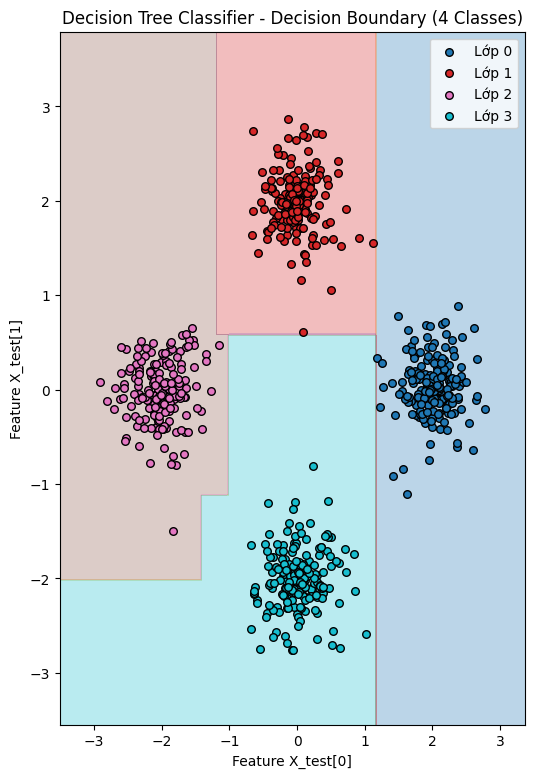

In [21]:
D, L = genPoints.Cloud(D=2,K=4,N=200)
featureX  = np.linspace(min(D[:, 0]), max(D[:, 0]), num=100)
featureY  = np.linspace(min(D[:, 1]), max(D[:, 1]), num=100)
feature_names = [f"X < {round(v, 2)}" for v in featureX] + [f"Y < {round(v, 2)}" for v in featureY]
combinedFeature = np.concatenate((featureX, featureY))

newX = (D[:, 0, None] < featureX).astype(int)
newY = (D[:, 1, None] < featureY).astype(int)
newD = np.c_[newX, newY]
tree_root = build_tree(newD, L, current_depth=0, max_depth=5)

# Generate test data
D_test, _ = genPoints.Cloud(D=2,K=4,N=200)
# --- BƯỚC 1: XÁC ĐỊNH VÙNG VẼ ĐỒ THỊ ---
x_min, x_max = D_test[:, 0].min() - 0.5, D_test[:, 0].max() + 0.5
y_min, y_max = D_test[:, 1].min() - 0.5, D_test[:, 1].max() + 0.5

# --- BƯỚC 2: TẠO LƯỚI ĐIỂM DÀY ĐẶC (MESHGRID) ---
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]

# --- BƯỚC 3: MÃ HÓA LƯỚI ĐIỂM THEO ĐÚNG 20 NGƯỠNG ĐÃ TÍNH ---
grid_X = (grid_points[:, 0, None] < featureX).astype(int)
grid_Y = (grid_points[:, 1, None] < featureY).astype(int)
grid_encoded = np.c_[grid_X, grid_Y]

# --- BƯỚC 4: BẮT CÂY QUYẾT ĐỊNH DỰ ĐOÁN CHO TOÀN BỘ LƯỚI ---
grid_predictions = []
# for sample in grid_encoded:
#     pred = predict_forest(tree_root, sample)
#     if isinstance(pred, np.ndarray):
#         pred = pred[0]
#     grid_predictions.append(pred)
pred = predict_tree(tree_root, grid_encoded)
grid_predictions = np.array(pred).reshape(xx.shape)

# --- BƯỚC 5: TIẾN HÀNH VẼ ĐỒ THỊ CHO N LỚP ---
plt.figure(figsize=(6, 9))

# 5.1 Tìm tất cả các lớp duy nhất có trong dữ liệu thực tế (N lớp)
unique_classes = np.unique(L)
num_classes = len(unique_classes)

# 5.2 Định nghĩa bảng màu đa lớp (ví dụ 'tab10' hoặc 'Set1' hỗ trợ rất tốt tới 10 lớp phân biệt)
# Bạn cũng có thể dùng 'brg' hoặc tự tạo danh sách màu nếu muốn cố định màu sắc nền
cmap_chosen = 'tab10' 

# Vẽ nền màu phân chia không gian (Hàm contourf tự động gán dải màu của cmap theo số lớp)
plt.contourf(xx, yy, grid_predictions, alpha=0.3, cmap=cmap_chosen)

# 5.3 Sử dụng vòng lặp để vẽ các chấm điểm dữ liệu thực tế
# Lấy dải màu chuẩn từ bảng màu để chấm điểm trùng khớp với tone màu của vùng nền tương ứng
colors = plt.cm.get_cmap(cmap_chosen)(np.linspace(0, 1, num_classes))

for idx, cls in enumerate(unique_classes):
    plt.scatter(
        D[L == cls, 0], 
        D[L == cls, 1], 
        color=colors[idx],         # Tự động gán màu tương ứng với lớp
        edgecolors='k', 
        label=f'Lớp {cls}',        # Tự động hiển thị đúng tên/số của lớp
        s=30
    )

# 5.4 Cài đặt các thông số hiển thị đồ thị tổng quát
plt.title(f"Decision Tree Classifier - Decision Boundary ({num_classes} Classes)")
plt.xlabel("Feature X_test[0]")
plt.ylabel("Feature X_test[1]")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()

# Hiển thị biểu đồ lên màn hình
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_19300\4257387618.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_chosen)(np.linspace(0, 1, num_classes))


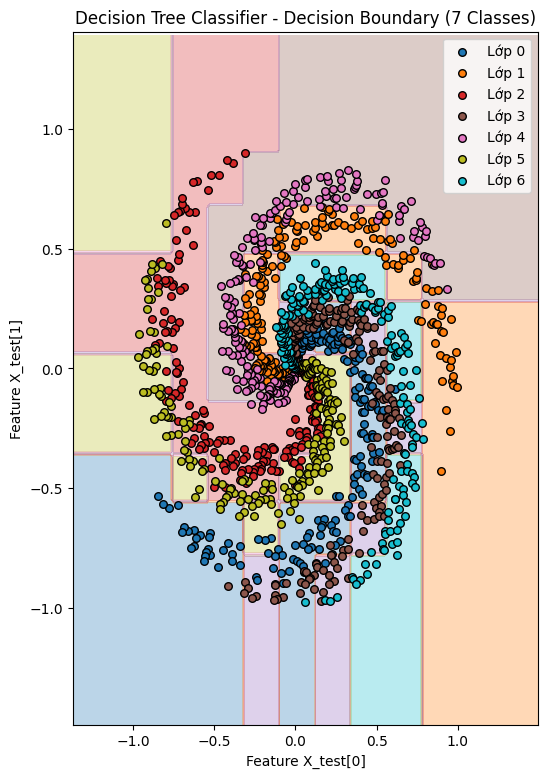

In [22]:
D, L = genPoints.Spiral(D=2,K=7,N=200)
featureX  = np.linspace(min(D[:, 0]), max(D[:, 0]), num=10)
featureY  = np.linspace(min(D[:, 1]), max(D[:, 1]), num=10)
feature_names = [f"X < {round(v, 2)}" for v in featureX] + [f"Y < {round(v, 2)}" for v in featureY]
combinedFeature = np.concatenate((featureX, featureY))

newX = (D[:, 0, None] < featureX).astype(int)
newY = (D[:, 1, None] < featureY).astype(int)
newD = np.c_[newX, newY]
# tree_root = build_tree(newD, L, feature_names, current_depth=0, max_depth=15)
forest = build_forest(newD, L, n_trees=100, max_depth=15)

# Generate test data
D_test, _ = genPoints.Spiral(D=2,K=5,N=200)
# --- BƯỚC 1: XÁC ĐỊNH VÙNG VẼ ĐỒ THỊ ---
x_min, x_max = D_test[:, 0].min() - 0.5, D_test[:, 0].max() + 0.5
y_min, y_max = D_test[:, 1].min() - 0.5, D_test[:, 1].max() + 0.5

# --- BƯỚC 2: TẠO LƯỚI ĐIỂM DÀY ĐẶC (MESHGRID) ---
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]

# --- BƯỚC 3: MÃ HÓA LƯỚI ĐIỂM THEO ĐÚNG 20 NGƯỠNG ĐÃ TÍNH ---
grid_X = (grid_points[:, 0, None] < featureX).astype(int)
grid_Y = (grid_points[:, 1, None] < featureY).astype(int)
grid_encoded = np.c_[grid_X, grid_Y]

# --- BƯỚC 4: BẮT CÂY QUYẾT ĐỊNH DỰ ĐOÁN CHO TOÀN BỘ LƯỚI ---
grid_predictions = []
pred = predict_forest(forest, grid_encoded)
grid_predictions = np.array(pred).reshape(xx.shape)

# --- BƯỚC 5: TIẾN HÀNH VẼ ĐỒ THỊ CHO N LỚP ---
plt.figure(figsize=(6, 9))

# 5.1 Tìm tất cả các lớp duy nhất có trong dữ liệu thực tế (N lớp)
unique_classes = np.unique(L)
num_classes = len(unique_classes)

# 5.2 Định nghĩa bảng màu đa lớp (ví dụ 'tab10' hoặc 'Set1' hỗ trợ rất tốt tới 10 lớp phân biệt)
# Bạn cũng có thể dùng 'brg' hoặc tự tạo danh sách màu nếu muốn cố định màu sắc nền
cmap_chosen = 'tab10' 

# Vẽ nền màu phân chia không gian (Hàm contourf tự động gán dải màu của cmap theo số lớp)
plt.contourf(xx, yy, grid_predictions, alpha=0.3, cmap=cmap_chosen)

# 5.3 Sử dụng vòng lặp để vẽ các chấm điểm dữ liệu thực tế
# Lấy dải màu chuẩn từ bảng màu để chấm điểm trùng khớp với tone màu của vùng nền tương ứng
colors = plt.cm.get_cmap(cmap_chosen)(np.linspace(0, 1, num_classes))

for idx, cls in enumerate(unique_classes):
    plt.scatter(
        D[L == cls, 0], 
        D[L == cls, 1], 
        color=colors[idx],         # Tự động gán màu tương ứng với lớp
        edgecolors='k', 
        label=f'Lớp {cls}',        # Tự động hiển thị đúng tên/số của lớp
        s=30
    )

# 5.4 Cài đặt các thông số hiển thị đồ thị tổng quát
plt.title(f"Decision Tree Classifier - Decision Boundary ({num_classes} Classes)")
plt.xlabel("Feature X_test[0]")
plt.ylabel("Feature X_test[1]")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()

# Hiển thị biểu đồ lên màn hình
plt.show()



# Number prediction

In [4]:


# 1. Đường dẫn tới thư mục cha chứa 10 folder (Sửa lại cho đúng với máy của bạn)
data_dir = "MNIST_digit_dataset/train/"  

X_data = []
y_label = []

# 2. Vòng lặp quét qua 10 thư mục từ 0 đến 9
for label in range(10):
    # Đường dẫn đến từng folder con, ví dụ: "du_lieu_anh/0/"
    folder_path = os.path.join(data_dir, str(label))
    
    # Tìm tất cả các file ảnh trong folder đó (hỗ trợ cả .jpg, .png, .jpeg)
    search_path = os.path.join(folder_path, "*.[jp][pn]*[g]")
    image_paths = glob.glob(search_path)
    
    print(f"Đang tải Folder {label}: Tìm thấy {len(image_paths)} ảnh.")
    
    for img_path in image_paths:
        # Đọc ảnh ở dạng ảnh xám (Grayscale) vì là ảnh số từ 0-9
        # Nếu muốn đọc ảnh màu, hãy bỏ cv2.IMREAD_GRAYSCALE
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            # RẤT QUAN TRỌNG: Đảm bảo tất cả các ảnh có cùng kích thước (ví dụ: 28x28)
            img_resized = cv2.resize(img, (28, 28))
            
            # Thêm ảnh và nhãn tương ứng vào danh sách
            X_data.append(img_resized)
            y_label.append(label)

# 3. Chuyển đổi danh sách thành mảng NumPy
X = np.array(X_data)  # Kích thước: (Số_lượng_ảnh, 28, 28)
y = np.array(y_label) # Kích thước: (Số_lượng_ảnh,)

print("\n--- TẢI DỮ LIỆU THÀNH CÔNG ---")
print("Kích thước tập dữ liệu X:", X.shape)
print("Kích thước tập nhãn y:", y.shape)


Đang tải Folder 0: Tìm thấy 5923 ảnh.


KeyboardInterrupt: 

In [9]:
import numpy as np

# Giả sử X và y là 2 mảng bạn vừa mất thời gian xử lý xong
print("Đang lưu dữ liệu vào ổ cứng...")

# Lưu chung X và y vào file tên là 'du_lieu_so_vi_viet.npz'
np.savez_compressed('du_lieu_so_vi_viet.npz', X_data=X, y_label=y)

print("Đã lưu xong! Bây giờ bạn có thể tắt máy.")


Đang lưu dữ liệu vào ổ cứng...
Đã lưu xong! Bây giờ bạn có thể tắt máy.


In [5]:
file_name = "du_lieu_so_vi_viet.npz"
data_loaded = np.load(file_name)

# 2. Rút các mảng dữ liệu ra bằng các Key đã lưu từ trước
X = data_loaded['X_data']
X = X.reshape(X.shape[0], -1)
y = data_loaded['y_label']

In [ ]:
import os
import numpy as np
from PIL import Image



# ==========================================
# CHẠY ĐÁNH GIÁ ĐỘ CHÍNH XÁC (ACCURACY SCORE)
# ==========================================

# Bước 1: Load dữ liệu test
print("Đang load dữ liệu test từ thư mục New_MNIST/test/...")
test_path = "New_MNIST/test/"
X_test, y_test = load_mnist_test_data(test_path)
np.savez_compressed('MINIST.npz', X_data=X_test, y_label=y_test)

print(f"Đã load xong! Số lượng mẫu test: {X_test.shape[0]} | Số đặc trưng: {X_test.shape[1]}")



Đang load dữ liệu test từ thư mục New_MNIST/test/...
Đã load xong! Số lượng mẫu test: 18005 | Số đặc trưng: 784


In [ ]:
forestNumber = myRFLibs.build_forest(X=X,y=y,max_depth=15,n_trees=15,max_features=15)
# Bước 2: Dự đoán nhãn cho toàn bộ tập dữ liệu test bằng Forest đã build
print("Đang tiến hành dự đoán nhãn cho tập dữ liệu test...")
y_pred = myRFLibs.predict_forest(forestNumber, X_test)

# Bước 3: Tính toán độ chính xác
accuracy = np.mean(y_pred == y_test) * 100

print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
print(f"Độ chính xác (Accuracy): {accuracy:.2f}%")
print(f"Số mẫu đoán đúng: {np.sum(y_pred == y_test)} / {len(y_test)}")

Đang tiến hành dự đoán nhãn cho tập dữ liệu test...


NameError: name 'predict_forest' is not defined

In [13]:
np.mean(y_pred == y_test)

np.float64(0.9965009719522355)

In [11]:
import RF_Model as model
model.save_model(filename="forestNumber.pkl",forest=forestNumber)

Model saved to forestNumber.pkl


In [13]:
loadedModel = model.load_model("forestNumber.pkl")
test_dir = "New_MNIST/test/2/11106.png" 
img = cv2.imread(test_dir, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (28, 28))
sample = img_resized.flatten().reshape(-1,28*28)
predict_forest(loadedModel,sample)

Model loaded from forestNumber.pkl


error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4217: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'
